# 2.5 Second Order Methods

* The previous notebook only looks at algorithms requiring the value of the function and 1st derivative of the function
* In this notebook we will look at algorithms of finding minimum of a function using value, derivative as well as Hessian (double derivative) information.  
* These methods are sometimes called the second order methods

Load plotting library and define structure to store intermediate data

In [24]:
using CairoMakie

In [25]:
struct Point1D
    x::Float64
    fvalue::Float64
end

---

# **Example 2.5.1**

Let's try to find the minimum of the function $h(x)=(x^3-x)^2$.  Make it a habit to always plot the graph (if you can) and visualise how the function looks like

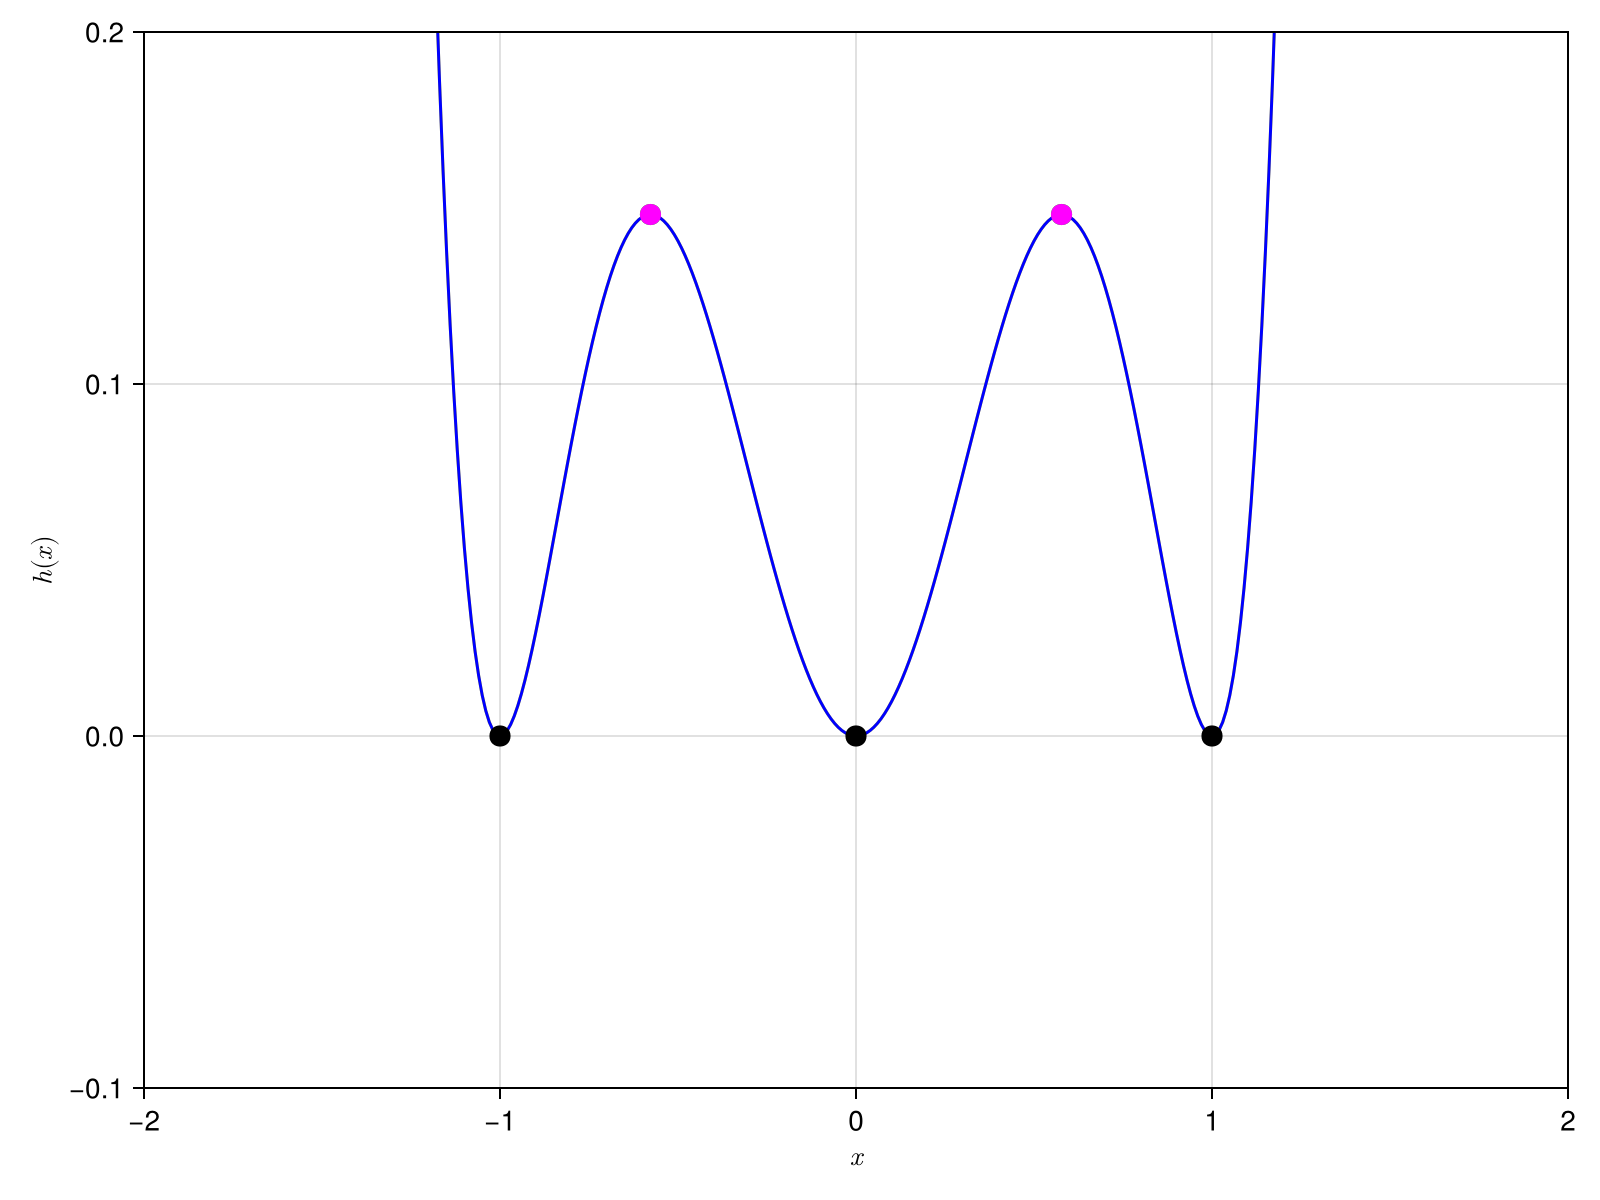

CairoMakie.Screen{IMAGE}


In [26]:
h(x)=(x^3-x)^2
∇h(x)=2*(x^3-x)*(3x^2-1);
Hessianh(x)=12*x*(x^3-x)+2*(3*x^2-1)^2; # Second derivative
xplot=-2:0.01:2
yplot=[h(x) for x in xplot];
fig = Figure(backgroundcolor = :transparent,size=(800,600))
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"$h(x)$",limits=(-2,2,-0.1,0.2),backgroundcolor = :transparent)
lines!(ax,xplot,yplot;color=:blue)
scatter!(ax,[0, -1, 1],h.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax,[1/sqrt(3), -1/sqrt(3)],h.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)

# Save the figure
save("../figures/ManyMinimums01.png", fig)

display(fig)

* The local minimum of the function is located at $x=-1,0,1$ indicated by the black dots. 
* Note that for this function there is a maximum at $x=\pm\sqrt{1/3}$ indicated by the magenta dots.

We have used the standard gradient descent method to find the minimum in the previous notebook.  Now we look at the Newton method. Consider Taylor series of a  function $f(x)$ expanded about $x=x_0$

$f(x) =f(x_0)+f'(x_0)(x-x_0)+\frac{f''(x_0) }{2!}(x-x_0)^{2}$.

Differentiate with respect to $x$ gives

$\frac{df}{dx}(x) =f'(x_0)+f''(x_0)(x-x_0)$

At a local minimum, $df/dx=0$.

$x=x_0-f'(x_0)/f''(x_0)$

So Newton's method can be thought of as fitting a 2nd order Taylor's polynomial about point $x_0$ and then find the minimum of this 2nd order Taylor's polynomial.  The update equation for the Newton method is then

$x^{(k+1)}=x^{(k)}-g^{(k)}/r^{(k)}$

where  $g^{(k)}=\frac{df}{dx}(x^{(k)})$ and $r^{(k)}=\frac{d^2f}{dx^2}(x^{(k)})$ is the first and second derivative  of the function $f(x)$ evaluated at the previous guess $x^{(k)}$. 

I will now graphically illustrate the Newton method.

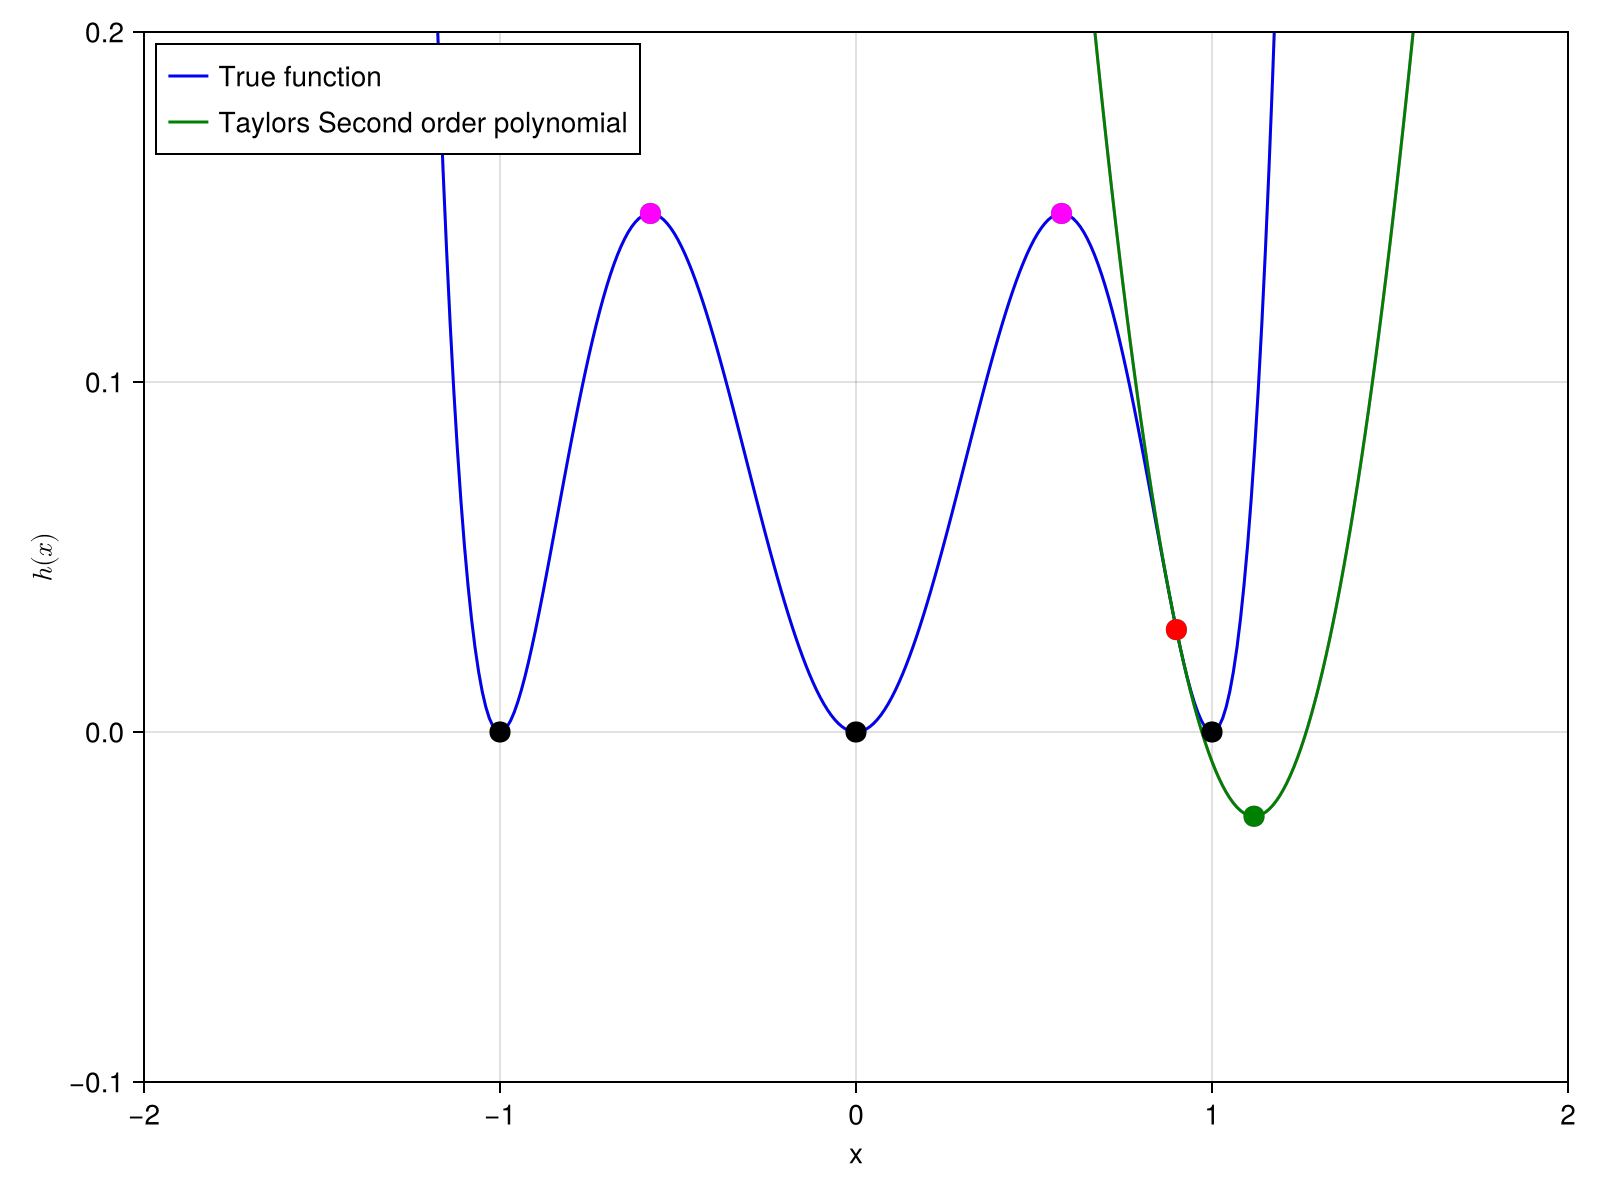

CairoMakie.Screen{IMAGE}


In [27]:
fig = Figure(backgroundcolor = :transparent,size=(800,600))
ax = Axis(fig[1, 1], xlabel = "x", ylabel = L"$h(x)$",limits=(-2,2,-0.1,0.2),backgroundcolor = :transparent)
lines!(ax,xplot,yplot;color=:blue,label="True function")


x0=0.9
f2ndOrderTaylor(x,x0)=h(x0)+∇h(x0)*(x-x0)+(Hessianh(x0)/2.0)*(x-x0)^2
lines!(ax,xplot,f2ndOrderTaylor.(xplot,x0);color=:green, label="Taylors Second order polynomial")

xnewton=x0-∇h(x0)/Hessianh(x0)

scatter!(ax,xnewton,f2ndOrderTaylor(xnewton,x0);color=:green,markersize=15)
scatter!(ax,x0,h(x0);color=:red,markersize=15)

scatter!(ax,[0, -1, 1],h.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax,[1/sqrt(3), -1/sqrt(3)],h.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)

axislegend(ax,position=:lt)


# Save the figure
save("../figures/ManyMinimums02.png", fig)

display(fig)

* For this example, the true function is blue line above.  The true location of the minimum is given by the black dot.  
* If the initial guess is at $x_0=0.9$ (given by the red dot in the figure above), then, after the first iteration,  the Newton method will predict the location to be at the green dot (which is the fitted 2nd order Taylor polynomial about $x_0=0.9$)
* The Newton method assumes that the green dot is closer to the black dot than the original red dot.

We can code up the update equations for the Newton method 

$x^{(k+1)}=x^{(k)}-g^{(k)}/r^{(k)}$

($g^{(k)}=\frac{df}{dx}(x^{(k)})$ and $r^{(k)}=\frac{d^2f}{dx^2}(x^{(k)})$ is the first and second derivative  of the function $f(x)$ evaluated at the previous guess $x^{(k)}$) below

In [28]:
x0=0.9 #initial guess of x0
x=x0
data_Newton=[Point1D(x0,h(x0))]
for i in 1 : 20
    x-=Hessianh(x)\∇h(x) #update equation for the Newton method
    push!(data_Newton,Point1D(x,h(x)))
end

In [29]:
data_Newton

21-element Vector{Point1D}:
 Point1D(0.9, 0.029240999999999975)
 Point1D(1.1180383415069102, 0.07813169165795499)
 Point1D(1.0365899460770065, 0.00596684442404486)
 Point1D(1.0049270862755146, 9.85477253796149e-5)
 Point1D(1.000106051277926, 4.500180878731018e-8)
 Point1D(1.000000050578152, 1.023259945612181e-14)
 Point1D(1.0000000000000115, 5.33269971929404e-28)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 ⋮
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)
 Point1D(1.0, 0.0)

We will now plot the convergence to see how fast the Newton method converges

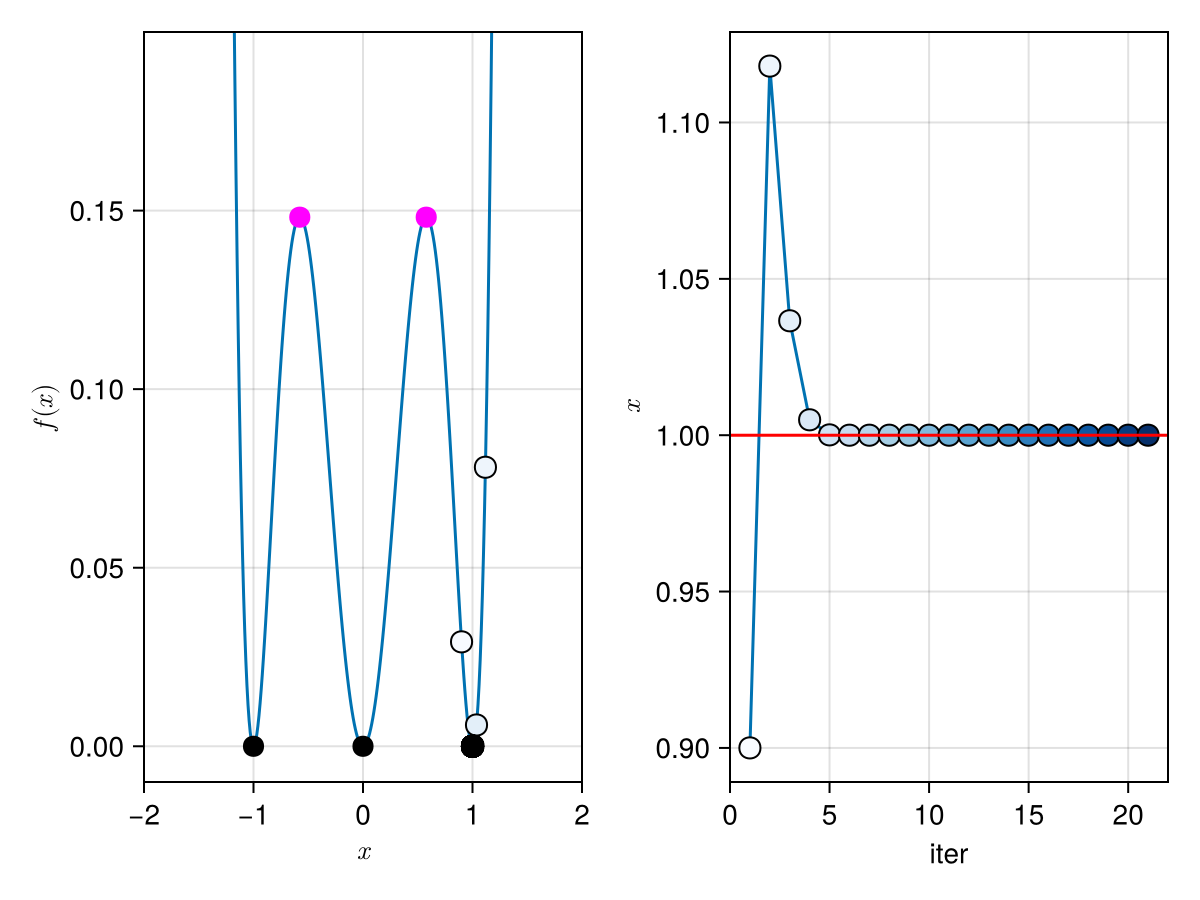

CairoMakie.Screen{IMAGE}


In [30]:
fig_conv = Figure()

ax_conv1 = Axis(fig_conv[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-2,2,-0.01,0.2))
lines!(ax_conv1,xplot,h.(xplot))
scatter!(ax_conv1,getproperty.(data_Newton,:x),getproperty.(data_Newton,:fvalue);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)


ax_conv2 = Axis(fig_conv[1, 2], xlabel = "iter", ylabel = L"x")
lines!(ax_conv2,getproperty.(data_Newton, :x),label="Gradient Descent")
scatter!(ax_conv2,getproperty.(data_Newton,:x);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)
hlines!(ax_conv2,1.0;color=:red)

scatter!(ax_conv1,[0, -1, 1],h.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax_conv1,[1/sqrt(3), -1/sqrt(3)],h.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)
fig_conv

# Save the figure
save("../figures/ManyMinimums02.png", fig_conv)

display(fig_conv)


* For Newton method, this problem converges in about 3 iterations.

Let's try to compute the same solution using  the Nesterov Momentum method and compare the rate of convergence with Newton method to see how fast it converges.

In [31]:
x0=0.9 #initial guess of xm
alpha=0.05 #learning rate
beta=0.9
v=0.0
x=x0
data_nm=[Point1D(x0,h(x0))]
for i in 1 : 20
    v =beta*v-alpha*∇h(x+beta*v) #update equations for the Nesterov Momentum 
    x+=v #update equations for the Nesterov Momentum 
    push!(data_nm,Point1D(x,h(x)))
end

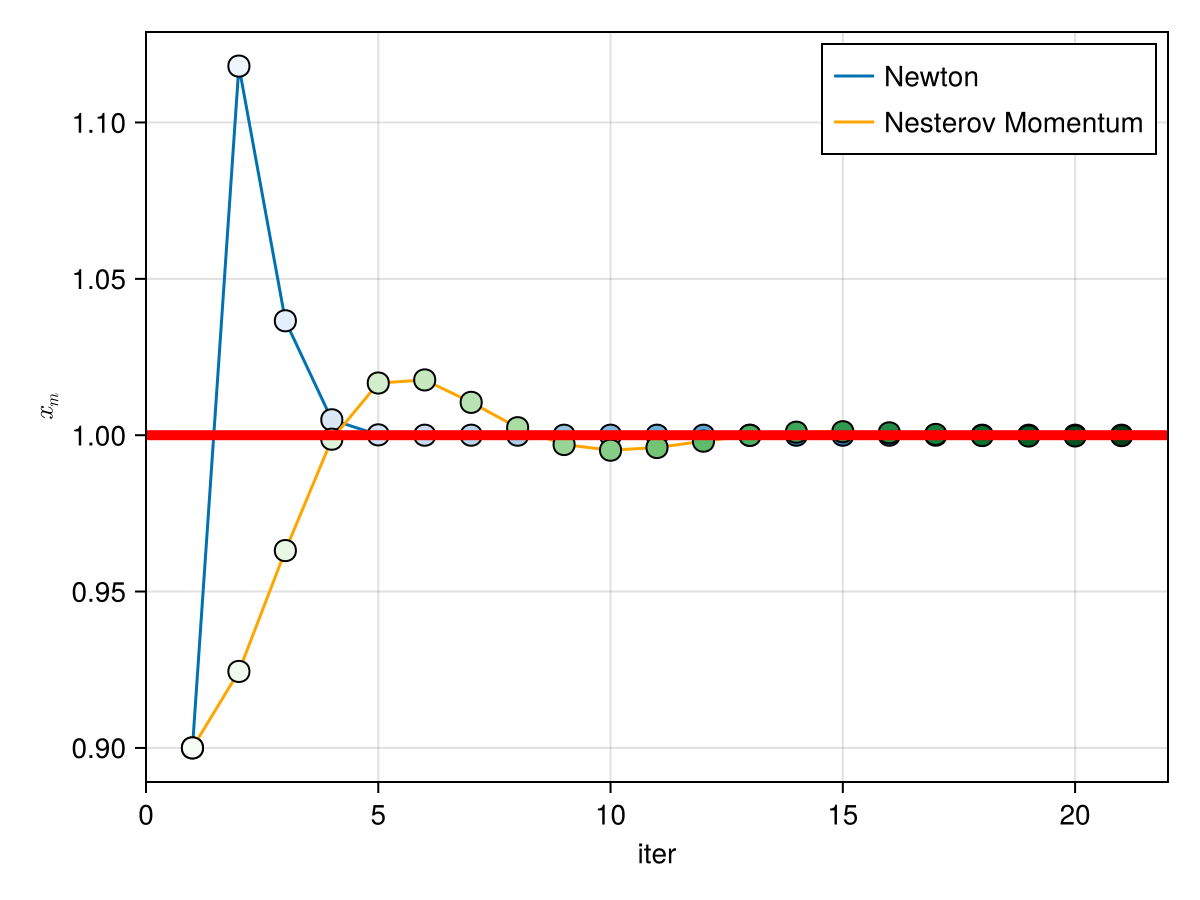

In [32]:
fig_conv = Figure()
ax_conv = Axis(fig_conv[1, 1], xlabel = "iter", ylabel = L"x_m")

lines!(ax_conv,getproperty.(data_Newton, :x),label="Newton")
scatter!(ax_conv,getproperty.(data_Newton,:x);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)

lines!(ax_conv,getproperty.(data_nm, :x),label="Nesterov Momentum",color=:orange)
scatter!(ax_conv,getproperty.(data_nm,:x);
    color=1:length(data_nm),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Greens,
    markersize=15)

axislegend(ax_conv,  position = :rt,orientation = :vertical)
hlines!(ax_conv,1.0;color=:red,linewidth=5.0)
fig_conv

* The graph above shows that Nesterov momentum method take about twice as long to converge compared to Newton method.
* In general Newton method is very fast, however, there can be some pitfalls.


---

### Beware some pitfalls of the Newton Method

* Note that  Newton method looks for regions where the derivative (gradient) is zero
* The gradient can be zero either at minimum or at maximum.
* If we start close to the maximum Newton method will find the maximum
* Let's see what happens if we try Newton method with a different guess

In [13]:
x0=0.4 #initial guess of x

data_Newton=[Point1D(x0,h(x0))]
for i in 1 : 20
    x0-=Hessianh(x0)\∇h(x0)
    push!(data_Newton,Point1D(x0,h(x0)))
end

Let's plot the convergence of Newton method

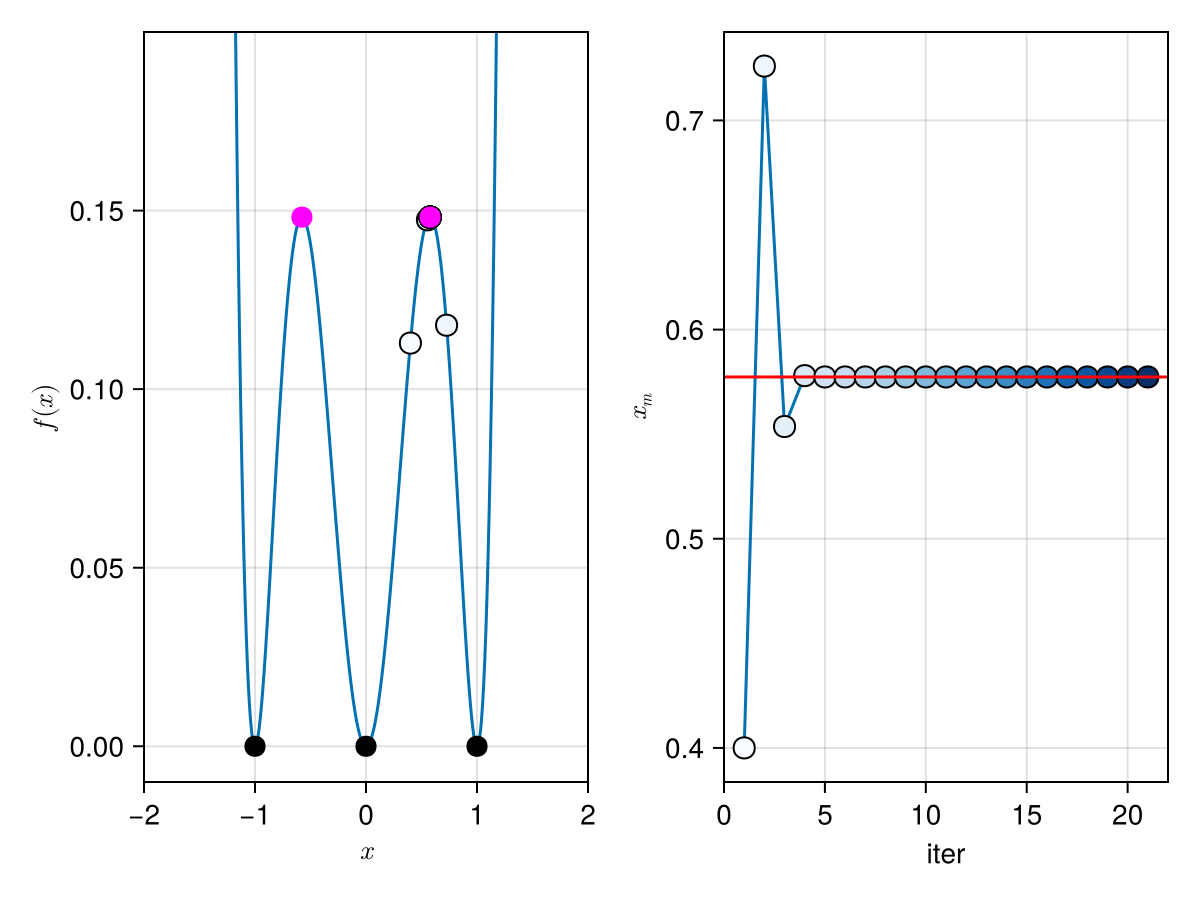

In [14]:
fig_conv = Figure()

ax_conv1 = Axis(fig_conv[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-2,2,-0.01,0.2))
lines!(ax_conv1,xplot,h.(xplot))
scatter!(ax_conv1,getproperty.(data_Newton,:x),getproperty.(data_Newton,:fvalue);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)


ax_conv2 = Axis(fig_conv[1, 2], xlabel = "iter", ylabel = L"x_m")
lines!(ax_conv2,getproperty.(data_Newton, :x),label="Gradient Descent")
scatter!(ax_conv2,getproperty.(data_Newton,:x);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)
hlines!(ax_conv2,+sqrt(1/3);color=:red)

scatter!(ax_conv1,[0, -1, 1],h.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax_conv1,[1/sqrt(3), -1/sqrt(3)],h.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)
fig_conv

If we start the calculation with initial guess $x_0=0.4$, the Newton method goes towards the local maximum (the magenta dot)!

We will now try Nesterov momentum method with initial guess $x_0=0.4$

In [15]:
x0=0.4 #initial guess of x0
alpha=0.05 #learning rate
beta=0.9
v=0.0
x=x0
data_nm=[Point1D(x0,h(x0))]
for i in 1 : 20
    v =beta*v-alpha*∇h(x+beta*v) #update equations for the Nesterov Momentum 
    x+=v #update equations for the Nesterov Momentum 
    push!(data_nm,Point1D(x,h(x)))
end

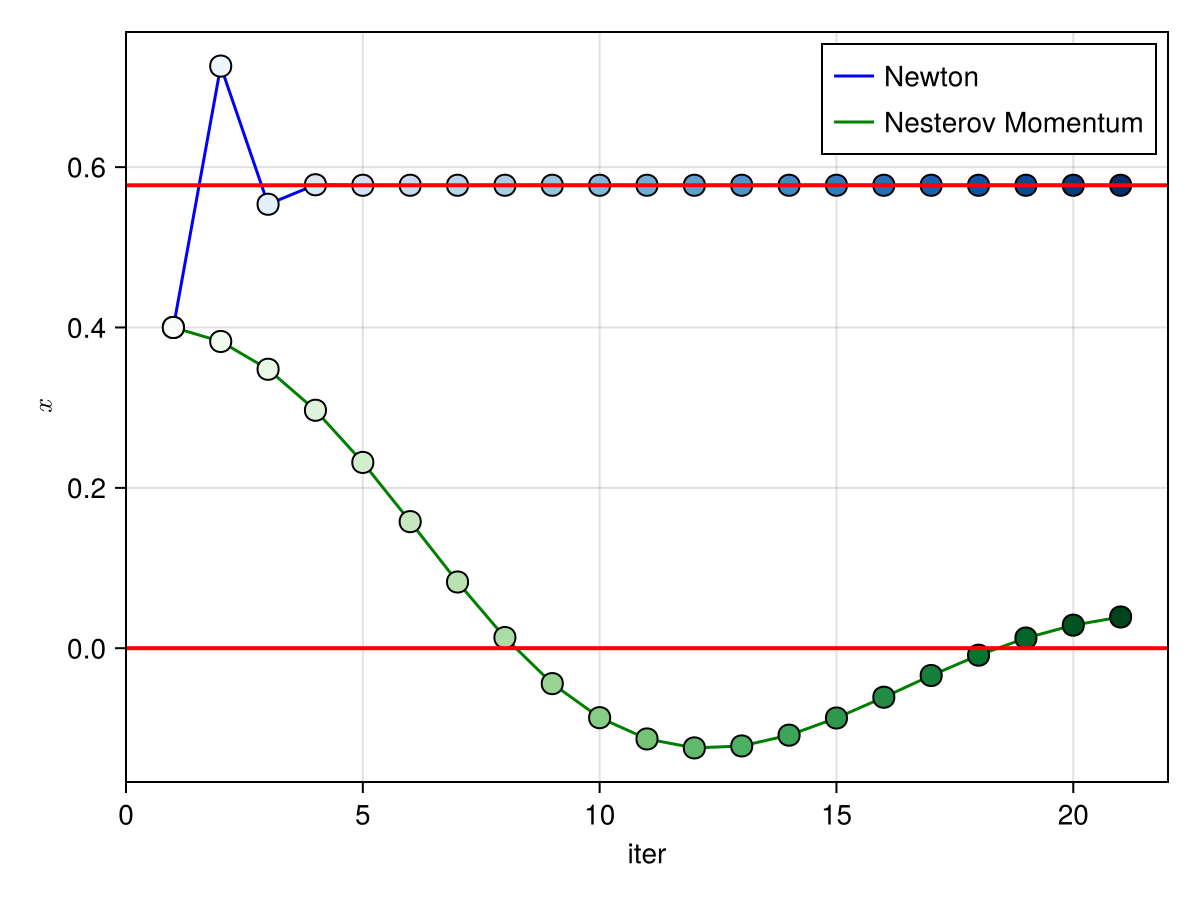

In [16]:
fig_conv = Figure()
ax_conv = Axis(fig_conv[1, 1], xlabel = "iter", ylabel = L"x")

lines!(ax_conv,getproperty.(data_Newton, :x),color=:blue,label="Newton")
scatter!(ax_conv,getproperty.(data_Newton,:x);
    color=1:length(data_Newton),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)

lines!(ax_conv,getproperty.(data_nm, :x),color=:green,label="Nesterov Momentum",)
scatter!(ax_conv,getproperty.(data_nm,:x);
    color=1:length(data_nm),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Greens,
    markersize=15)

axislegend(ax_conv,  position = :rt,orientation = :vertical)
hlines!(ax_conv,sqrt(1.0/3.0);color=:red,linewidth=2.0)
hlines!(ax_conv,0.0;color=:red,linewidth=2.0)
fig_conv

* The Nesterov Momentum method converges to the correct minimum at $x=0.0$
* The Newton method, even though faster, converges to the local maximum at $x=1/\sqrt{3}$
* In general, it is usually found that first order method (such as Nesterov momentum) can usually always converge to a minimum but but the convergence can take a long time.
* If you are close to the minimum, second order methods (such as Newton method) converges very fast.  However, if you are far away from the minimum, second order methods can converge to the wrong answer.

* In practice, it is advisable to try first order methods initially to try to get closer to the minimum.  Once you care close to the minimum, you would switch to the second order method.


---

**Class Demo 01:** Write a Julia program that implements the Newton's method to find the minimum of the function

$A(r)=2\pi r^2+\frac{2}{r}$

---

##   Newton Method For Multivariable Functions

The update equations for the Newton method for a multivariate function is not as straightforward as the methods shown above.  However, we can derive it for a function of two variables and then extending it to multi dimensions should be straightforward.  Consider the taylor series expansion (truncated at 2nd order) for a function of two variables

\begin{align}
f(x_1,x_2)\approx &f(x_{01},x_{02})+\frac{\partial f}{\partial x_1}(x_{01},x_{02})(x_1-x_{01})+\frac{\partial f}{\partial x_2}(x_{01},x_{02})(x_2-x_{02})\\
&+\frac{\partial^2 f}{\partial x_2\partial x_1}(x_{01},x_{02})(x_1-x_{01})(x_2-x_{02})\\
&+\frac{1}{2!}\frac{\partial^2 f}{\partial x_1^2}(x_{01},x_{02})(x_-x_{01})^2+\frac{1}{2!}\frac{\partial^2 f}{\partial x_2^2}(x_{01},x_{02})(x_2-x_{02})^2\\
\end{align}

If we want to find the minimum of of the function $f(x_1,x_2)$, we need to find $(x_1,x_2)$ where 

$\frac{\partial f}{\partial x_1}=0$ and $\frac{\partial f}{\partial x_2}=0$.

Differentiate the 2nd order Taylor series expansion and set to zero gives

\begin{align}
\frac{\partial f}{\partial x_1}(x_1,x_2) =&\frac{\partial f}{\partial x_1}(x_{01},x_{02})\\
&+\frac{\partial^2 f}{\partial x_2\partial x_1}(x_{01},x_{02})(x_2-x_{02})\\
&+\frac{\partial^2 f}{\partial x_1^2}(x_{01},x_{02})(x_1-x_{02})\\
=&0\\
\end{align}

\begin{align}
\frac{\partial f}{\partial x_2}(x_1,x_2) =&\frac{\partial f}{\partial x_2}(x_{01},x_{02})\\
&+\frac{\partial^2 f}{\partial x_2\partial x_1}(x_{01},x_{02})(x_1-x_{01})\\
&+\frac{\partial^2 f}{\partial x_2^2}(x_{01},x_{02})(x_2-x_{02})\\
=&0\\
\end{align}

Solving for $x_1$ and $x_2$ gives the update equations  for the Newton method 



\begin{equation}
\begin{Bmatrix}
   x_1^{(k+1)} \\ 
      x_2^{(k+1)} 
\end{Bmatrix}=\begin{Bmatrix}
   x_1^{(k)} \\ 
      x_2^{(k)} \\ 
\end{Bmatrix}-\begin{bmatrix}H_{11} &H_{12}\\
H_{21} &H_{22}
\end{bmatrix}^{-1}
\begin{Bmatrix}
   \frac{\partial f}{\partial x_1}(x_1^{(k)},x_2^{(k)}) \\ 
      \frac{\partial f}{\partial x_2}(x_1^{(k)},x_2^{(k)}) 
\end{Bmatrix}
\end{equation}



In general for a function of $N$ variables, Newton method can be written as

$\vec{x}^{(k+1)}=\vec{x}^{(k)}-\left(\mathbf{H}^{(k)}\right)^{-1}\vec{g}^{(k)}$

where $\mathbf{H}$ is the $N\times N$ Hessian matrix 

$H_{ij}=\frac{\partial^2 f}{\partial x_i\partial x_j}$

and $\vec{x}$ is an $N \times 1$ vector.

The implementation of the Newton method in Julia is given below


 



In [19]:
struct Point2D
    x1::Float64
    x2::Float64
    fvalue::Float64
end

quad(x)=(3.0/2.0)*x[1]^2+2*x[1]*x[2]+3*x[2]^2-2*x[1]+8*x[2] # Define the function
function Gradient_quad(x)
    d1=3*x[1]+2*x[2]-2 #df/dx1
    d2=6*x[2]+2*x[1]+8 #df/dx2
    return [d1,d2]
end


function Hessian_quad(x)
    return [3 2;2 6] # This is the Hessian of the function which we will use later.
end

x0=[4.0,4.0]#initial guess of xm

data_Newton=[Point2D(x0...,quad(x0))]
x=x0
for i in 1 : 20
    x-=Hessian_quad(x)\Gradient_quad(x)
    push!(data_Newton,Point2D(x...,quad(x)))
end

data_Newton

21-element Vector{Point2D}:
 Point2D(4.0, 4.0, 128.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 ⋮
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)
 Point2D(2.0, -2.0, -10.0)

---


Let's now try the Himmelblau Function

$f(x_1,x_2)=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$

This function has one local maxima at $(x_1,x_2)=(-0.270845...,-0.923039..)$ and 4 local minima at $(x_1,x_2)=(3.0,2.0), (-2.805118...,3.13132...),(-3.779310...,-3.283136),(3.584428,-1.848126..)$.  

The derivatives are 



$\frac{\partial f}{\partial x_1}(x_1,x_2)=4x_1(x_1^2+x_2-11)+2(x_1+x_2^2-7)$

$\frac{\partial f}{\partial x_2}(x_1,x_2)=2(x_1^2+x_2-11)+4x_2(x_1+x_2^2-7)$

and the components of the Hessian are

$\frac{\partial^2 f}{\partial x_1^2}(x_1,x_2)=12x_1^2+4x_2-42$

$\frac{\partial^2 f}{\partial x_1 \partial x_2}(x_1,x_2)=4x_1+4x_2$

$\frac{\partial^2 f}{\partial x_2 \partial x_1}(x_1,x_2)=4x_1+4x_2$

$\frac{\partial^2 f}{\partial x_2^2}(x_1,x_2)=4x_1+12x_2^2-26$

Define the Himmelblau function, its gradients and Hessian and plotting it to see how it looks like.

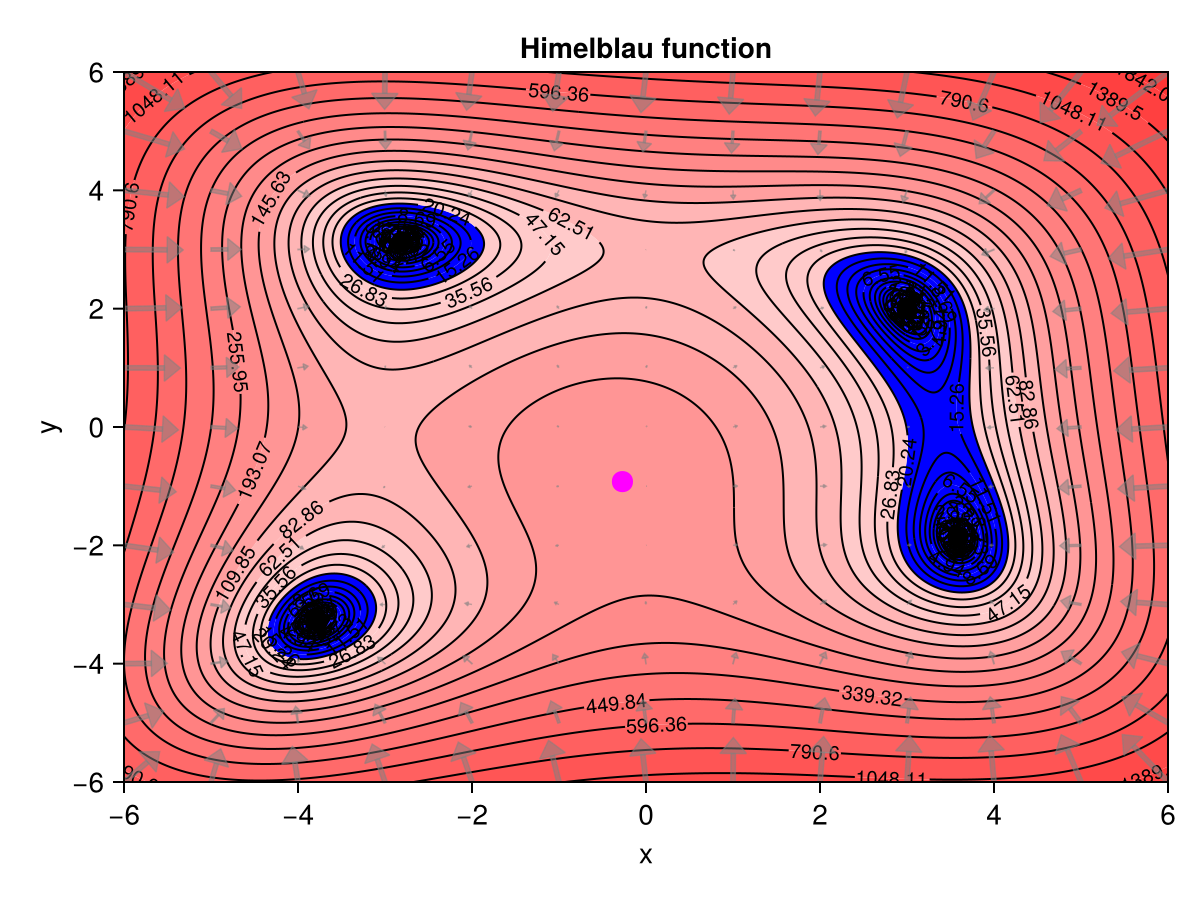

CairoMakie.Screen{IMAGE}


In [20]:
himmelblau(x)=(x[1]^2+x[2]-11)^2+(x[1]+x[2]^2-7)^2


function Gradient_himmelblau(x)
    d1=4*x[1]*(x[1]^2+x[2]-11)+2*(x[1]+x[2]^2-7)
    d2=2*(x[1]^2+x[2]-11)+4*x[2]*(x[1]+x[2]^2-7)
    return [d1,d2]
end

function Hessian_himmelblau(x)
    return [12*x[1]^2+4*x[2]-42 4*x[1]+4*x[2];4*x[1]+4*x[2] 12*x[2]^2+4*x[1]-26]
end

x1range=-6:0.02:6;
x2range=-6:0.02:6;

funcplot = [himmelblau([x1,x2]) for x1 in x1range, x2 in x2range]

fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = "y",title = "Himelblau function",limits=(-6,6.0,-6.0,6.0))
levels = 10.0.^range(-2, 4; length=50)
contourf!(ax,x1range,x2range,funcplot; levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels,color=:black)
scatter!(ax,[-0.270845],[-0.923039];color=:magenta,markersize=15)
scatter!(ax,[3.0,-2.805118,-3.779310,3.584428],[2.0,3.13132,-3.283136,-1.848126],color=:black,markersize=15)

x1range_arrow=-6:1:6;
x2range_arrow=-6:1:6;
arrowplot = [Gradient_himmelblau([x1,x2]) for x1 in x1range_arrow, x2 in x2range_arrow]
arrows2d!(ax,x1range_arrow,x2range_arrow,-getindex.(arrowplot,1),-getindex.(arrowplot,2);color=(:grey, 0.5),lengthscale = 0.001)

display(fig)

Using Standard Gradient Descent

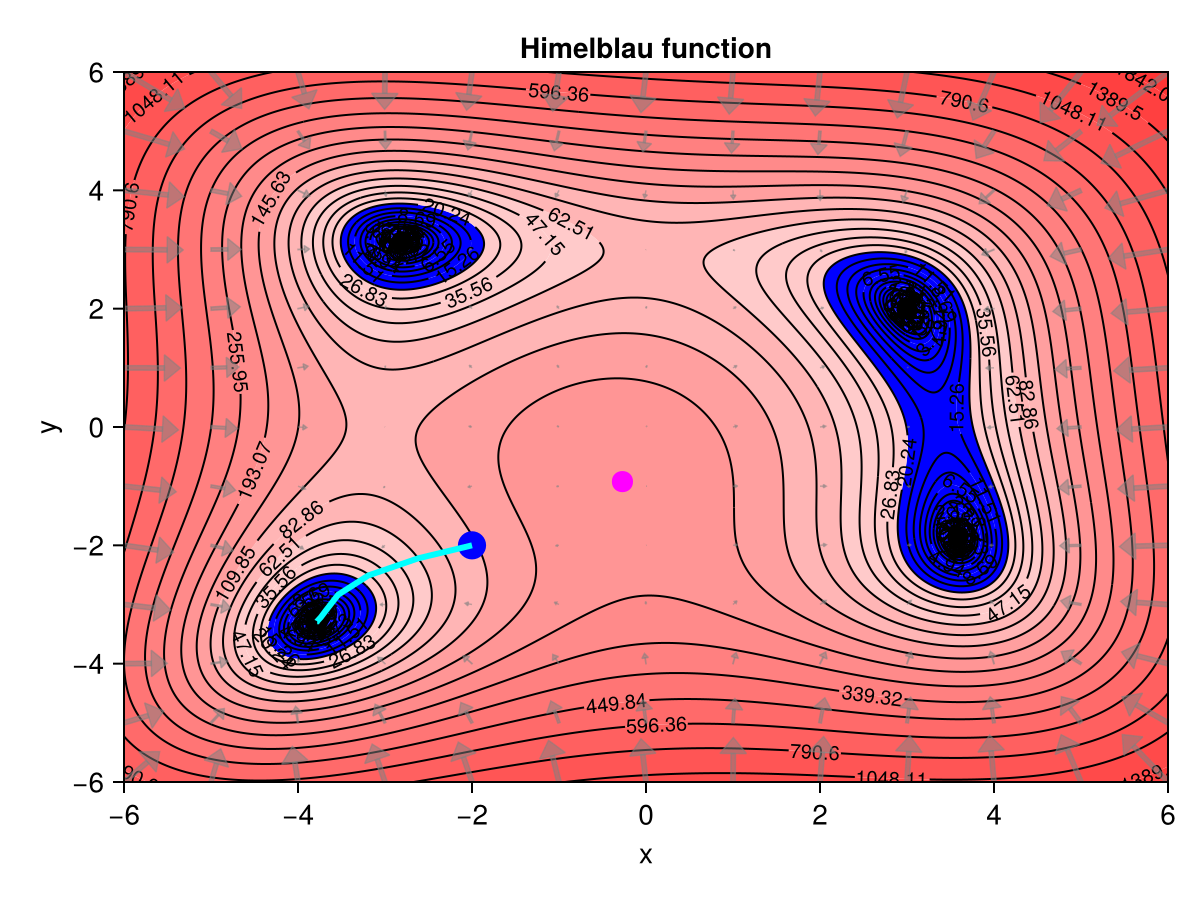

In [21]:
x0=[-2.0,-2.0] #initial guess of xm
alpha=0.01 #learning rate
data=[Point2D(x0...,himmelblau(x0))]
x=x0
for i in 1 : 20
    x-=alpha*Gradient_himmelblau(x)
    push!(data,Point2D(x...,himmelblau(x)))
end
scatter!(ax,x0[1],x0[2],color=:blue,markersize=20)
lines!(ax,getproperty.(data, :x1),getproperty.(data, :x2),color=:cyan,linewidth=3,label="Gradient Descent") 
fig

Now try Newton method with Himmelblau with initial guess $x_0=[-2,-2]$

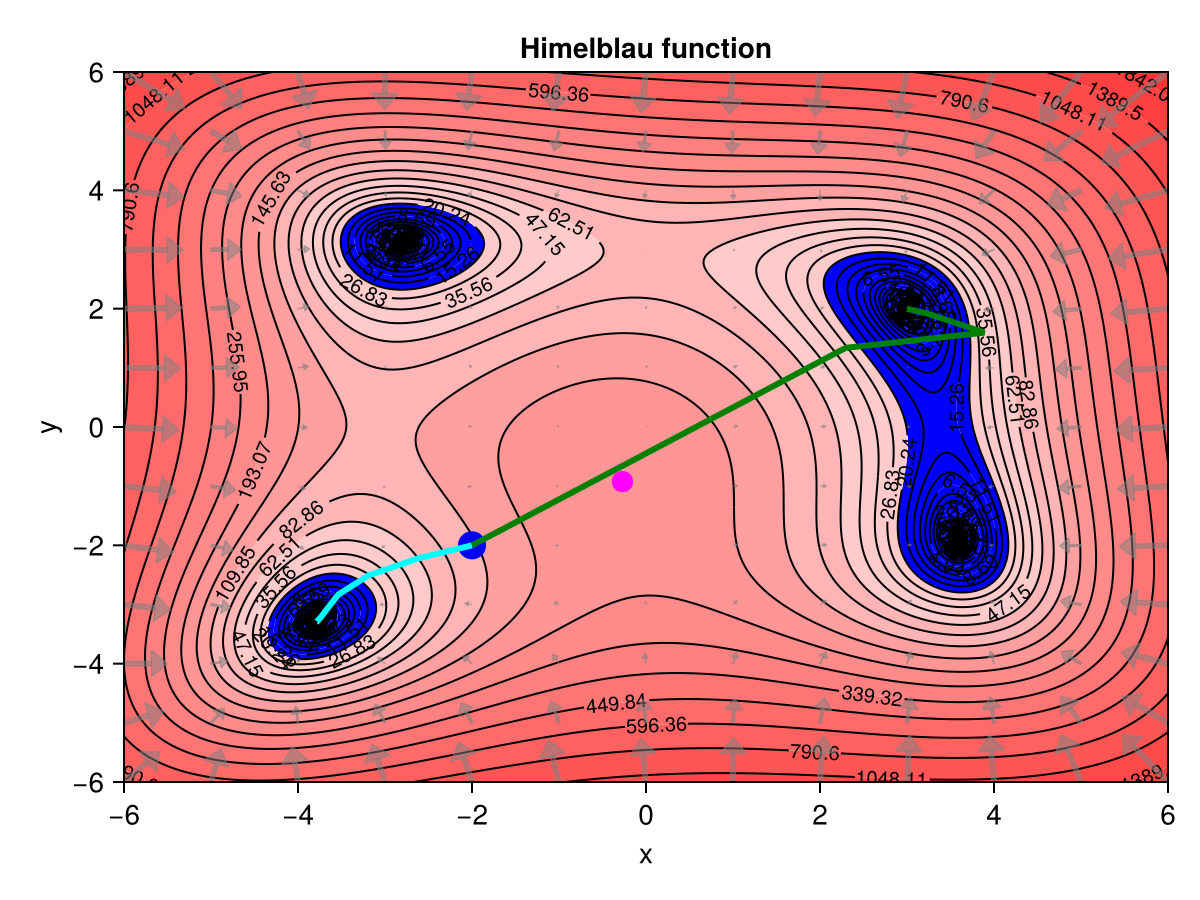

In [22]:
x0=[-2.0,-2.0]#initial guess of x0

data_Newton=[Point2D(x0...,himmelblau(x0))]

x=x0
for i in 1 : 50
    x-=Hessian_himmelblau(x)\Gradient_himmelblau(x)
    push!(data_Newton,Point2D(x...,himmelblau(x)))
end

lines!(ax,getproperty.(data_Newton, :x1),getproperty.(data_Newton, :x2),linewidth=3,color=:green,label="Newton") 
fig

In [23]:
data_Newton


51-element Vector{Point2D}:
 Point2D(-2.0, -2.0, 106.0)
 Point2D(2.295774647887324, 1.3380281690140845, 27.775159384379172)
 Point2D(3.890345134033711, 1.595352594656927, 33.1531457103013)
 Point2D(3.2392670282048375, 1.915129519506457, 1.9910600181057867)
 Point2D(3.0253020169071303, 1.9896539418099064, 0.020449388328767935)
 Point2D(3.000324004744422, 1.999889719422051, 3.376730016233299e-6)
 Point2D(3.00000005541271, 1.999999977956334, 9.744174283056258e-14)
 Point2D(3.0000000000000018, 1.9999999999999993, 1.1438483125704671e-28)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 ⋮
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)
 Point2D(3.0, 2.0, 0.0)

Note that Newton method converges to a different location than the standard Gradient Descent method.  This can happen, that you get different answers with different method!

<u>Exercise Ex02:</u> Run  Newton method again but use the  initial guess $(x_1,x_2)=(-0.5,-1.0)$.  Can you explain what happens?